**CSI 4106 Introduction to Artificial Intelligence (Fall 2025)** <br/>
*Assignment 3: Alien Pet Health, Deep Learning*

# Identification

Name: Anoushka Jawale

Student Number: 300233148

--

## 0. Preamble

In [ ]:
# Suggested librairies

import os
from pathlib import Path
import urllib.request
import urllib.error

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from keras.metrics import F1Score

In [ ]:
URL_DATA = "https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean.csv"

COLS_TO_STANDARDIZE = ["thermoreg_reading", "enzyme_activity_index", "stress_variability"]
COLS_TO_NORMALIZE = ["dual_lobe_signal"]
COLS_TO_ENCODE = ["habitat_zone"]
COLS_NO_PREPROC = ["activity_score","fasting_flag"]
TARGET   = "health_outcome"

COLUMNS_DATA = COLS_TO_STANDARDIZE + COLS_TO_NORMALIZE + COLS_TO_ENCODE + COLS_NO_PREPROC

RANDOM_STATE = 42
TEST_SIZE    = 0.20

SCORING = {
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
}

PRIMARY_METRIC = F1Score(threshold=0.5, average="macro")

In [ ]:
def load_dataset_or_fail(url=URL_DATA, cache_dir="data", *, verbose=True):

    """
    Load the dataset, downloading it once and caching locally.

    - Extracts the filename from the URL.
    - Stores it under `cache_dir`.
    - Validates required columns and target.

    Returns
    -------
    X : pandas.DataFrame
    y : numpy.ndarray
    """

    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    filename = Path(url).name
    cache_path = cache_dir / filename

    # 1) Download if not cached

    if not cache_path.exists():
        if verbose:
            print(f"Downloading dataset from {url} ...")
        try:
            urllib.request.urlretrieve(url, cache_path)
            if verbose:
                print(f"Saved to {cache_path}")
        except (urllib.error.URLError, urllib.error.HTTPError) as e:
            raise RuntimeError(f"Failed to download dataset: {e}")

    # 2) Read the CSV

    try:
        df = pd.read_csv(cache_path)
    except Exception as e:
        raise RuntimeError(f"Failed to read {cache_path}: {e}")

    # 3) Validate content

    if TARGET not in df.columns:
        raise ValueError(f"Missing target column '{TARGET}' in {cache_path}")

    df = df.dropna(subset=[TARGET]).copy()

    missing = set(COLUMNS_DATA).difference(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {cache_path}: {sorted(missing)}")

    # 4) Split features and target

    X = df[COLUMNS_DATA]
    y = df[TARGET].astype(int).to_numpy().reshape(-1,1) # (n,) -> (n,1)

    return X, y

In [ ]:
def set_seed(seed: int = 42):

    """Fix most randomness sources for reproducible demos."""

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [ ]:
set_seed(42)

# 1. Data

For this assignment, we use a dataset in which all tasks from the prior assignment have been thoroughly completed. Notably, Assignment 3 uses the dataset [alien_pet_health-realism-clean.csv](https://raw.githubusercontent.com/turcotte/csi4106-f25/main/assignments-data/a2/alien_pet_health-realism-clean.csv), from assignment Assignment 2.

## Load the dataset

- Read the CSV file (`alien_pet_health-realism-clean.csv`).
- Show the shape of the data, as well as the first five rows.

In [ ]:
# Python code

X, y = load_dataset_or_fail(URL_DATA)
print(X.shape)
print(y.shape)
display(X.describe())
X.head()

Saved to data/alien_pet_health-realism-clean.csv
(5000, 7)
(5000, 1)


,thermoreg_reading,enzyme_activity_index,stress_variability,dual_lobe_signal,activity_score,fasting_flag
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,50.000140,100.005800,0.000580,2.001180,2.967200,0.401800
std,8.000065,29.989012,5.000697,3.000172,1.290138,0.490311
min,21.000000,0.000000,-18.000000,-6.500000,1.000000,0.000000
25%,44.600000,80.000000,-3.400000,-0.400000,2.000000,0.000000
50%,50.100000,100.000000,0.000000,2.500000,3.000000,0.000000
75%,55.200000,120.000000,3.425000,4.500000,4.000000,1.000000
max,77.800000,231.000000,18.700000,8.900000,5.000000,1.000000


,thermoreg_reading,enzyme_activity_index,stress_variability,dual_lobe_signal,habitat_zone,activity_score,fasting_flag
0,52.6,97.0,-3.5,3.6,c2,2,0
1,41.8,105.0,10.5,3.4,c1,2,0
2,56.2,126.0,9.6,5.5,c2,5,0
3,57.7,106.0,-4.0,-4.1,c1,4,0
4,34.5,73.0,0.3,2.3,c4,5,1


## Data splitting

- Split the dataset into training (70%), validation (15%) and test (15%) sets.
- Ensure that this split occurs before any preprocessing to avoid data leakage.

In [ ]:
# Python code

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)


## Data Pre-Processing

In [ ]:
# Python code

def make_preprocessor(COLS_TO_STANDARDIZE, COLS_TO_NORMALIZE, COLS_TO_ENCODE, COLS_NO_PREPROC):

    """
    Build a ColumnTransformer for the Alien Pet Health dataset.

    - Standardizes selected columns (zero mean, unit variance)
    - Normalizes selected columns to [0,1]
    - One-hot encodes categorical columns
    - Passes specified columns through unchanged

    Note: Columns in COLS_NO_PREPROC must already be numeric (e.g., 0/1 flags).
    """

    preprocessor = ColumnTransformer(
        transformers=[
            ("standardize", StandardScaler(), COLS_TO_STANDARDIZE),
            ("normalize", MinMaxScaler(), COLS_TO_NORMALIZE),
            ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COLS_TO_ENCODE),
            ("keep", "passthrough", COLS_NO_PREPROC),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor

def fit_transform_inputs(preprocess: ColumnTransformer, X_train: pd.DataFrame,
                         X_val: pd.DataFrame, X_test: pd.DataFrame):

    """
    Fit the preprocessor on train; transform train/val/test consistently.
    Returns numpy arrays and input_dim for Keras.
    """

    Xtr = preprocess.fit_transform(X_train)
    Xva = preprocess.transform(X_val)
    Xte = preprocess.transform(X_test)
    input_dim = Xtr.shape[1]

    return Xtr, Xva, Xte, input_dim

In [ ]:
# Python code

preprocess = make_preprocessor(COLS_TO_STANDARDIZE, COLS_TO_NORMALIZE, COLS_TO_ENCODE, COLS_NO_PREPROC)

Xtr, Xva, Xte, input_dim = fit_transform_inputs(preprocess, X_train, X_val, X_test)

# 2. Tasks

The tasks are arranged in a specific order to optimize brevity and clarity. Although you have some flexibility in organizing your code, it is important that your teaching assistant can effortlessly identify the code segments related to each task.

Suggestions: Start with a small model (e.g., 8 units) and train for 10–20 epochs using default hyperparameters. Expand exploration only after observing reasonable learning curves and metrics. Create reusable helper functions and consistently plot training and validation loss curves. Log experiments concisely, plotting loss curves only for the best model for each task.

**The numbers for the precision, recall, F1 score and AUC score in addition to the figures indicate the model neither overfits not underfits. In the figures, the training and validation sets fall with to similar losses and rise to similar F1 scores and metrics are very similar.**

In [ ]:
# Python code


## Build a Simple Feed-Forward Network

In [ ]:
# Python code

def build_network(input_dim):
    """Single hidden layer model: 8 units, ReLU, sigmoid output."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.Precision(name='precision'),

            keras.metrics.Recall(name='recall'),
            F1Score(name='f1', threshold=0.5, average='macro'),
            keras.metrics.AUC(name='auc')
        ]
    )
    return model


def plot_training_history(history, title="Training History"):
    """Plot loss and F1 score for train and validation sets."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['loss'], label='train_loss', color='pink')

    ax[0].plot(history.history['val_loss'], label='val_loss', color='green')
    ax[0].set_title(f'{title} - Loss')
    ax[0].set_xlabel('Epoch')

    ax[0].set_ylabel('Binary Crossentropy')
    ax[0].legend()

    if 'f1' in history.history:
        ax[1].plot(history.history['f1'], label='train_f1', color='pink')
        ax[1].plot(history.history['val_f1'], label='val_f1', color='green')
        ax[1].set_title(f'{title} - F1 Score')

        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('F1 Score')
        ax[1].legend()

    plt.show()


def evaluate_model(model, X_train, y_train, X_val, y_val):


    """Getthe precision, recall, f1, and ROC/AUC for both train and validation sets."""
    def get_metrics(X, y):
        y_pred = (model.predict(X) > 0.5).astype(int)
        return {
            'precision': precision_score(y, y_pred),
            'recall': recall_score(y, y_pred),
            'f1': f1_score(y, y_pred),
            'roc_auc': roc_auc_score(y, model.predict(X))
        }

    return {
        'train': get_metrics(X_train, y_train),
        'val': get_metrics(X_val, y_val)
    }




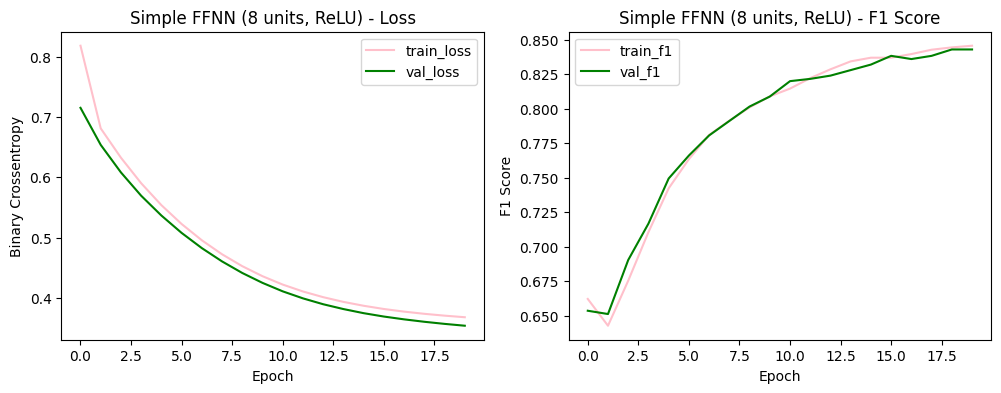

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
{'train': {'precision': 0.8394879369768586, 'recall': 0.8529264632316158, 'f1': 0.8461538461538461, 'roc_auc': np.float64(0.9185987296496825)}, 'val': {'precision': 0.8379446640316206, 'recall': 0.848, 'f1': 0.8429423459244533, 'roc_auc': np.float64(0.9240639999999999)}}


In [ ]:
set_seed(42)

simple_model = build_network(input_dim)

history = simple_model.fit(
    Xtr, y_train,
    validation_data=(Xva, y_val),
    epochs=20,
    batch_size=32,
    verbose=0
)

plot_training_history(history, title="Simple FFNN (8 units, ReLU)")
metrics = evaluate_model(simple_model, Xtr, y_train, Xva, y_val)
print(metrics)



## Overfitting

From the figures it can be seen that some overfitting has occurred when comparing the figures. The loss for the validation set increases while the loss for the training set decreased. In addition, the F1 score for the validation set does not improve while the training set rises. Thus means both that model’s performance on unseen data is getting worse — it’s not generalizing and that the model’s predictions on new data are no longer improving.

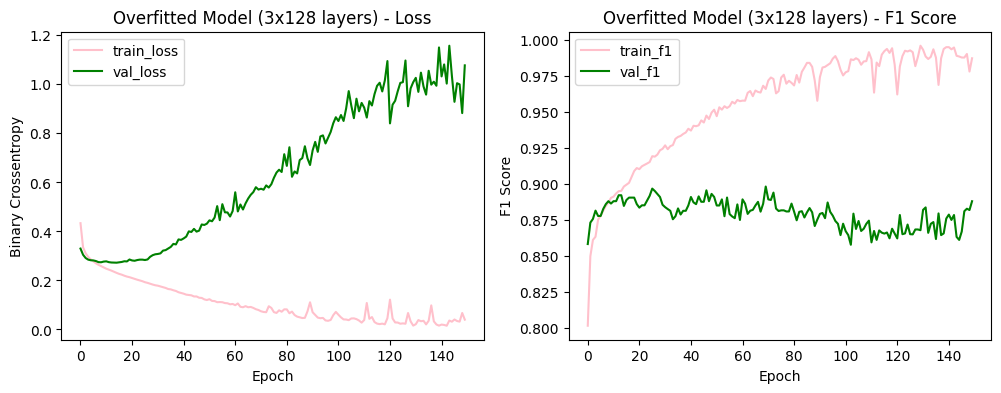

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


{'train': {'precision': 0.8394879369768586,
  'recall': 0.8529264632316158,
  'f1': 0.8461538461538461,
  'roc_auc': np.float64(0.9185987296496825)},
 'val': {'precision': 0.8379446640316206,
  'recall': 0.848,
  'f1': 0.8429423459244533,
  'roc_auc': np.float64(0.9240639999999999)}}

In [ ]:
# Python code

def build_overfit_model(input_dim):
    """Deliberately large model to overfit training data."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            F1Score(name='f1', threshold=0.5, average='macro'),
            keras.metrics.AUC(name='auc')
        ]
    )
    return model

set_seed(42)

overfit_model = build_overfit_model(input_dim)

history_overfit = overfit_model.fit(
    Xtr, y_train,validation_data=(Xva, y_val),
    epochs=150,batch_size=16,
    verbose=0
)

plot_training_history(history_overfit, title="Overfitted Model (3x128 layers)")
metrics_overfit = evaluate_model(simple_model, Xtr, y_train, Xva, y_val)
metrics_overfit



## Early Stopping

It can be seen that the early stopping strategy has improved the overfitted model's performance by allowing the validation loss to decrease slightly more an increase F1 score.

Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 13.


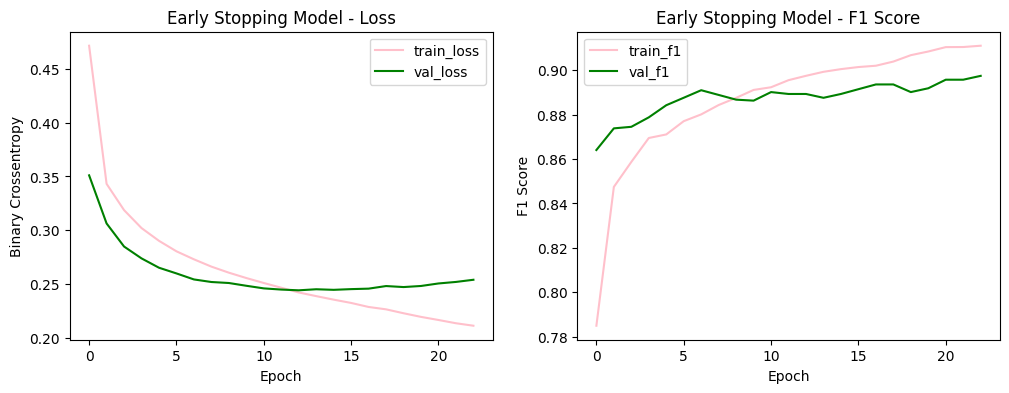

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


{'train': {'precision': 0.8804554079696395,
  'recall': 0.928464232116058,
  'f1': 0.9038227416605795,
  'roc_auc': np.float64(0.9682522420630606)},
 'val': {'precision': 0.8641509433962264,
  'recall': 0.916,
  'f1': 0.8893203883495145,
  'roc_auc': np.float64(0.96512)}}

In [ ]:
# Python code

early_stop_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,restore_best_weights=True,
    verbose=1
)

set_seed(42)
early_model = build_overfit_model(input_dim)

history_early = early_model.fit(
    Xtr, y_train,
    validation_data=(Xva, y_val),
    epochs=150,
    batch_size=32, callbacks=[early_stop_cb],
    verbose=0
)

plot_training_history(history_early, title="Early Stopping Model")
metrics_early = evaluate_model(early_model, Xtr, y_train, Xva, y_val)
metrics_early


## Architecture Exploration

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
125/125 ━━━━━

,layers,units,activation,train_precision,train_recall,train_f1,train_roc_auc,val_precision,val_recall,val_f1,val_roc_auc
23,3,64,tanh,0.864787,0.905453,0.884653,0.951755,0.858209,0.920,0.888031,0.957600
22,3,64,relu,0.872270,0.918959,0.895006,0.962995,0.855019,0.920,0.886320,0.957776
20,3,32,relu,0.863745,0.906953,0.884822,0.954776,0.857678,0.916,0.885880,0.955952
21,3,32,tanh,0.855038,0.899950,0.876919,0.950105,0.854478,0.916,0.884170,0.955392
14,2,64,relu,0.853964,0.921461,0.886429,0.956294,0.836364,0.920,0.876190,0.955328
15,2,64,tanh,0.845510,0.908954,0.876085,0.947648,0.832117,0.912,0.870229,0.952032
13,2,32,tanh,0.835876,0.904452,0.868813,0.940937,0.829091,0.912,0.868571,0.942240
7,1,64,tanh,0.818349,0.892446,0.853793,0.926733,0.831502,0.908,0.868069,0.927584
6,1,64,relu,0.836329,0.884442,0.859713,0.933462,0.833948,0.904,0.867562,0.934016
19,3,16,tanh,0.830783,0.896448,0.862368,0.940619,0.823741,0.916,0.867424,0.944144


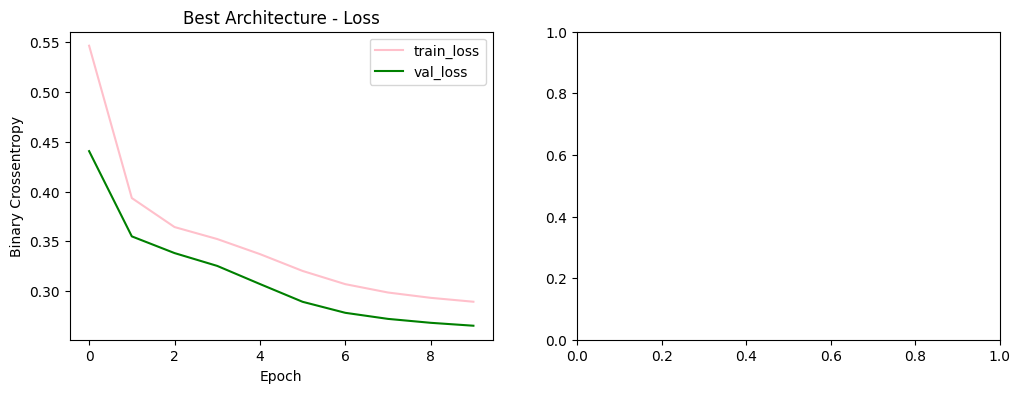

In [ ]:
# ------------------------------
# Evaluate model (train + val)
# ------------------------------
def evaluate_model(model, X_train, y_train, X_val, y_val):
    """Return train and validation metrics flattened."""
    def get_metrics(X, y):
        y_pred = (model.predict(X) > 0.5).astype(int)
        return {
            'precision': precision_score(y, y_pred),
            'recall': recall_score(y, y_pred),
            'f1': f1_score(y, y_pred),
            'roc_auc': roc_auc_score(y, model.predict(X))
        }

    train_metrics = get_metrics(X_train, y_train)
    val_metrics = get_metrics(X_val, y_val)

    # Flatten and prefix with 'train_' or 'val_'
    flat_metrics = {}
    for key, val in train_metrics.items():
        flat_metrics[f'train_{key}'] = val
    for key, val in val_metrics.items():
        flat_metrics[f'val_{key}'] = val

    return flat_metrics

# ------------------------------
# Build any model
# ---------
def build_custom_model(input_dim, num_layers=1, units=8, activation='relu'):
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for _ in range(num_layers):
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            # optional F1 metric during training, not needed for final evaluation
            keras.metrics.AUC(name='auc')
        ]
    )
    return model

# ------------------------------
# Architecture collection
# ------
results = []
some_architectures = [
    (1, 8), (1, 16), (1, 32), (1, 64),
    (2, 8), (2, 16), (2, 32), (2, 64),
    (3, 8), (3, 16), (3, 32), (3, 64)
]
activations = ['relu', 'tanh']

for num_layers, units in some_architectures:
    for act in activations:
        set_seed(42)  # your reproducibility function
        model = build_custom_model(input_dim, num_layers, units, act)
        es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
        history = model.fit(
            Xtr, y_train,
            validation_data=(Xva, y_val),
            epochs=10,
            batch_size=32,
            verbose=0,
            callbacks=[es]
        )
        metrics = evaluate_model(model, Xtr, y_train, Xva, y_val)
        results.append({
            'layers': num_layers,
            'units': units,
            'activation': act,
            **metrics
        })

# ------------------------------
# Convert to df & rank
# ------
df_results = pd.DataFrame(results)
display(df_results.sort_values(by='val_f1', ascending=False).head(10))

# Best configuration
best_cfg = df_results.sort_values(by='val_f1', ascending=False).iloc[0]

# ------------------------------
# Train thee best model
# ------
set_seed(42)
best_model = build_custom_model(input_dim, int(best_cfg.layers), int(best_cfg.units), best_cfg.activation)
history_best = best_model.fit(
    Xtr, y_train,
    validation_data=(Xva, y_val),
    epochs=10,
    verbose=0
)

plot_training_history(history_best, title="Best Architecture")


## Regularization

Overall both the L2 penalty and Dropout techniques were effective for model performance, although dropout was better. The best obersved technique was dropout rate 0.25.

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


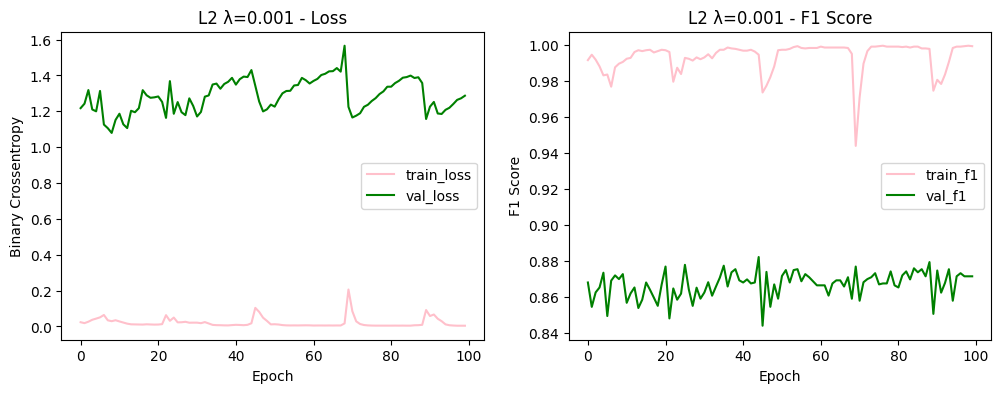

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


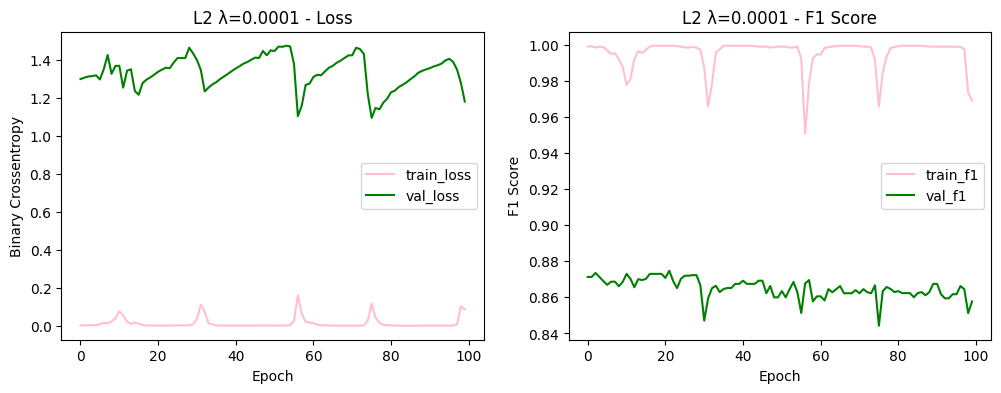

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


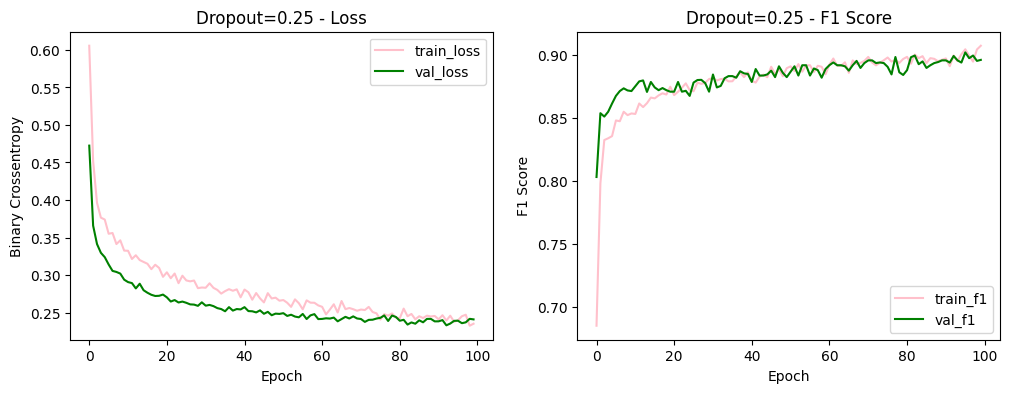

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


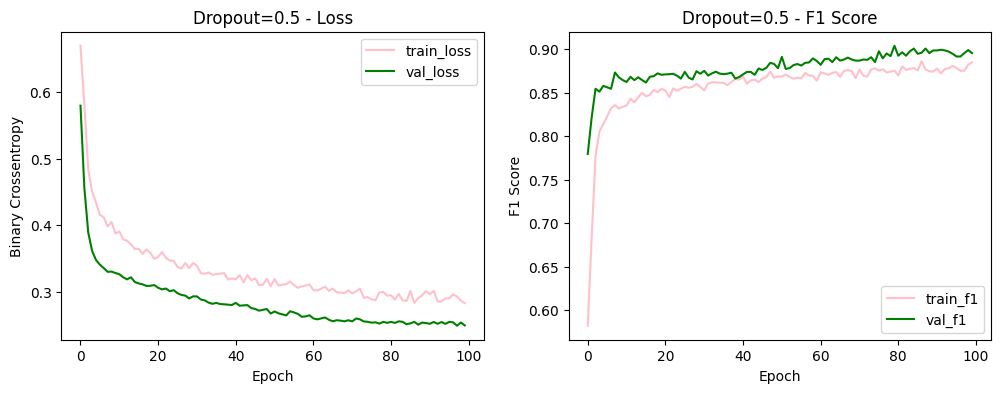

,dropout,train_precision,train_recall,train_f1,train_roc_auc,val_precision,val_recall,val_f1,val_roc_auc
0,0.25,0.899335,0.947474,0.922777,0.976605,0.862963,0.932,0.896154,0.964032
1,0.50,0.885277,0.926463,0.905402,0.966978,0.868421,0.924,0.895349,0.962128


In [ ]:
# Python code
# ====================
# (5a) Regularization - L2 Penalty
# ======

def build_l2_model(input_dim, num_layers=2, units=64, activation='relu', l2_lambda=0.001):
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for _ in range(num_layers):
        model.add(layers.Dense(units, activation=activation,
                               kernel_regularizer=regularizers.l2(l2_lambda)))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            F1Score(name='f1', threshold=0.5, average='macro'),
            keras.metrics.AUC(name='auc')
        ]
    )
    return model

lambdas = [0.001, 0.0001]
results_l2 = []

for lam in lambdas:
    set_seed(42)
    model = early_model
    history = model.fit(Xtr, y_train, validation_data=(Xva, y_val), epochs=100, batch_size=32, verbose=0)
    metrics = evaluate_model(model, Xtr, y_train, Xva, y_val)
    results_l2.append({'lambda': lam, **metrics})
    plot_training_history(history, title=f"L2 λ={lam}")

pd.DataFrame(results_l2)

# ===============================
# (5b) Regularization - Dropout
# =======

def build_dropout_model(input_dim, num_layers=2, units=64, activation='relu', dropout_rate=0.5):
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for _ in range(num_layers):
        model.add(layers.Dense(units, activation=activation))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            F1Score(name='f1', threshold=0.5, average='macro'),
            keras.metrics.AUC(name='auc')
        ]
    )
    return model

drop_rates = [0.25, 0.5]
results_drop = []

for dr in drop_rates:
    set_seed(42)
    model = build_dropout_model(input_dim, dropout_rate=dr)
    history = model.fit(Xtr, y_train, validation_data=(Xva, y_val), epochs=100, batch_size=32, verbose=0)
    metrics = evaluate_model(model, Xtr, y_train, Xva, y_val)
    results_drop.append({'dropout': dr, **metrics})
    plot_training_history(history, title=f"Dropout={dr}")

pd.DataFrame(results_drop)

## Model Evaluation

In [ ]:


# =========================================================
# (6) Model Eval
# ==============

final_model = build_dropout_model(input_dim, num_layers=2, units=64, dropout_rate=0.25)

set_seed(42)
final_model.fit(np.vstack((Xtr, Xva)), np.vstack((y_train, y_val)), epochs=100, batch_size=32, verbose=0)
metrics_test = evaluate_model(final_model,Xtr, y_train, Xva, y_val)
metrics_test


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


{'train_precision': 0.9095354523227384,
 'train_recall': 0.9304652326163082,
 'train_f1': 0.9198813056379822,
 'train_roc_auc': np.float64(0.9762704940676237),
 'val_precision': 0.916030534351145,
 'val_recall': 0.96,
 'val_f1': 0.9375,
 'val_roc_auc': np.float64(0.980928)}

## Bonus - further improvements

In [ ]:
# Python code


# References

The following links were accessed for coding help:

https://www.geeksforgeeks.org/deep-learning/feedforward-neural-network/

https://www.geeksforgeeks.org/deep-learningusing-early-stopping-to-reduce-overfitting-in-neural-networks/

https://www.geeksforgeeks.org/machine-learning/regularization-in-machine-learning/

https://mookpreeyanuch.medium.com/a-beginners-guide-to-model-evaluation-in-machine-learning-6e4ad4a844b2


# Resources


If you use AI assistance, it is essential to meticulously document all interactions. Your report should specify the tools and their versions, accompanied by a complete transcript of these interactions. Most AI platforms automatically log conversations, so it is advisable to initiate a new conversation specifically for the assignment and consistently use this thread throughout your work. Ensure that this conversation remains focused exclusively on the assignment. Include the transcript of this conversation

#End of Assignment 3